In [ ]:
---

format: 
  html:
    toc: false
    page-layout: full
execute:
    echo: true
    
---

In [129]:
import altair as alt
import geopandas as gpd
import hvplot
import geopandas as gpd
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from shapely.geometry import Point
import warnings

 <h1> <center> MUSA 6310: Assignment 3 </center>

 <h3> <center> Dennis Espejo   </center>

In [130]:
neighborhoods= gpd.read_file("/Users/dennisespejo/Desktop/philadelphia-neighborhoods")
neighborhoods

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"POLYGON ((-75.06773 40.00540, -75.06765 40.005..."
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"POLYGON ((-75.01560 40.09487, -75.01768 40.092..."
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"POLYGON ((-75.18848 40.07273, -75.18846 40.072..."
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"POLYGON ((-75.21221 40.08604, -75.21210 40.086..."
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"POLYGON ((-75.18476 40.02829, -75.18426 40.027..."
...,...,...,...,...,...,...
154,PENNSPORT,Pennsport,Pennsport,11823.233108,6.492473e+06,"POLYGON ((-75.14654 39.93005, -75.14804 39.921..."
155,NEWBOLD,Newbold,Newbold,10052.570885,5.876853e+06,"POLYGON ((-75.16986 39.92312, -75.17015 39.921..."
156,WEST_PASSYUNK,West Passyunk,West Passyunk,10499.291848,6.494799e+06,"POLYGON ((-75.17630 39.92425, -75.17798 39.923..."
157,EAST_PASSYUNK,East Passyunk,East Passyunk,10987.761846,6.502097e+06,"POLYGON ((-75.15684 39.92897, -75.15712 39.927..."


In [131]:
#| echo: true
#| code-fold: true

import requests
import pandas as pd


api_key = 'e4257eb23558f9d666c87ad6dc303db358377420'


base_url = "https://api.census.gov/data/2022/acs/acs5"


params = {
    "get": "B03002_001E,B19013_001E,B15003_021E,B15003_022E,B15003_023E,B15003_024E,B15003_025E",
    "for": "tract:*",  
    "in": "state:42 county:101",  
    "key": api_key
}


response = requests.get(base_url, params=params)

if response.status_code != 200:
    print("Error: Failed to retrieve data")
    print(response.text)
else:
    print("Request successful")
    data = response.json()

  
    columns = data[0]  
    values = data[1:]  


    df = pd.DataFrame(values, columns=columns)
    
    
    df["college"] = (
 
    df["B15003_022E"].astype(int) +   # bachelors
    df["B15003_023E"].astype(int) +   # masters
    df["B15003_024E"].astype(int) +   # professional
    df["B15003_025E"].astype(int)     # doctorate
)


        
 


df.head()




Request successful


,B03002_001E,B19013_001E,B15003_021E,B15003_022E,B15003_023E,B15003_024E,B15003_025E,state,county,tract,college
0,1947,117250,0,763,591,235,170,42,101,000101,1759
1,2897,94974,23,1185,557,379,73,42,101,000102,2194
2,3486,98994,182,1029,213,146,141,42,101,000200,1529
3,3914,95234,88,1110,556,584,309,42,101,000300,2559
4,2675,86293,53,921,587,244,160,42,101,000401,1912


In [132]:
#| echo: true
#| code-fold: true

import requests
import pandas as pd


api_key = 'e4257eb23558f9d666c87ad6dc303db358377420'


base_url = "https://api.census.gov/data/2017/acs/acs5"


params = {
    "get": "B03002_001E,B19013_001E,B15003_021E,B15003_022E,B15003_023E,B15003_024E,B15003_025E",
    "for": "tract:*",  
    "in": "state:42 county:101",  
    "key": api_key
}


response = requests.get(base_url, params=params)

if response.status_code != 200:
    print("Error: Failed to retrieve data")
    print(response.text)
else:
    print("Request successful")
    data = response.json()

  
    columns = data[0]  
    values = data[1:]  


    df2 = pd.DataFrame(values, columns=columns)
    
    
    df2["college"] = (

    df2["B15003_022E"].astype(int) +   # bachelors
    df2["B15003_023E"].astype(int) +   # masters
    df2["B15003_024E"].astype(int) +   # professional
    df2["B15003_025E"].astype(int)     # doctorate
)


        
 


df2.head()




Request successful


,B03002_001E,B19013_001E,B15003_021E,B15003_022E,B15003_023E,B15003_024E,B15003_025E,state,county,tract,college
0,6735,33344,192,171,75,0,74,42,101,006700,320
1,3178,28264,75,133,11,0,14,42,101,007000,158
2,4155,40947,83,624,253,85,69,42,101,008000,1031
3,4157,17149,103,139,87,0,0,42,101,009400,226
4,3135,21788,152,227,61,0,0,42,101,009500,288


In [133]:
df["GEOID"] = df["state"] + df["county"] + df["tract"]
df2["GEOID"] = df2["state"] + df2["county"] + df2["tract"]

df_change = df.merge(
    df2,
    on="GEOID",
    suffixes=("_new", "_old")
)

In [134]:
df_change

,B03002_001E_new,B19013_001E_new,B15003_021E_new,B15003_022E_new,B15003_023E_new,B15003_024E_new,B15003_025E_new,state_new,county_new,tract_new,...,B19013_001E_old,B15003_021E_old,B15003_022E_old,B15003_023E_old,B15003_024E_old,B15003_025E_old,state_old,county_old,tract_old,college_old
0,3486,98994,182,1029,213,146,141,42,101,000200,...,30746,151,525,89,60,70,42,101,000200,744
1,3914,95234,88,1110,556,584,309,42,101,000300,...,84135,33,1024,483,448,218,42,101,000300,2173
2,2675,86293,53,921,587,244,160,42,101,000401,...,59221,43,872,627,182,146,42,101,000401,1827
3,3057,69267,39,663,238,290,76,42,101,000500,...,42135,48,366,210,210,75,42,101,000500,861
4,1536,97794,0,505,257,278,117,42,101,000600,...,77500,0,213,271,228,43,42,101,000600,755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,0,-666666666,0,0,0,0,0,42,101,980400,...,-666666666,0,0,0,0,0,42,101,980400,0
359,0,-666666666,0,0,0,0,0,42,101,980500,...,-666666666,0,0,0,0,0,42,101,980500,0
360,0,-666666666,0,0,0,0,0,42,101,980600,...,-666666666,0,0,0,0,0,42,101,980600,0
361,0,-666666666,0,0,0,0,0,42,101,980800,...,-666666666,0,0,0,0,0,42,101,980800,0


In [135]:
df_change["college_change"] = (
    df_change["college_new"] - df_change["college_old"]
)

In [136]:
import pygris

tracts = pygris.tracts(state = "PA", county = "Philadelphia")

Using the default year of 2021
Using FIPS code '42' for input 'PA'
Using FIPS code '101' for input 'Philadelphia'


In [137]:
tracts = tracts.merge(df_change, on="GEOID")

In [138]:
tracts=tracts.to_crs("EPSG:32129")

In [139]:
neighborhoods=neighborhoods.to_crs("EPSG:32129")

In [140]:
tract_centroids = tracts.copy()
tract_centroids["geometry"] = tract_centroids.geometry.centroid

joined = gpd.sjoin(
    tract_centroids,
    neighborhoods,
    predicate="within",
    how="left"
)

In [141]:
joined

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME_left,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,county_old,tract_old,college_old,college_change,index_right,NAME_right,LISTNAME,MAPNAME,Shape_Leng,Shape_Area
0,42,101,036700,42101036700,367,Census Tract 367,G5020,S,729908,0,...,101,036700,1855,640,88.0,NORTHERN_LIBERTIES,Northern Liberties,Northern Liberties,20685.015399,2.031376e+07
1,42,101,034702,42101034702,347.02,Census Tract 347.02,G5020,S,1032346,0,...,101,034702,860,42,25.0,PENNYPACK,Pennypack,Pennypack,24887.211825,3.468542e+07
2,42,101,034801,42101034801,348.01,Census Tract 348.01,G5020,S,1385962,5188,...,101,034801,366,353,27.0,PENNYPACK_WOODS,Pennypack Woods,Pennypack Woods,19811.033218,1.350941e+07
3,42,101,034802,42101034802,348.02,Census Tract 348.02,G5020,S,1232182,8015,...,101,034802,644,467,26.0,ASTON_WOODBRIDGE,Aston-Woodbridge,Aston-Woodbridge,17216.867194,1.414791e+07
4,42,101,034900,42101034900,349,Census Tract 349,G5020,S,1944025,8263,...,101,034900,403,404,29.0,TORRESDALE,Torresdale,Torresdale,35702.492498,6.513612e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,42,101,013602,42101013602,136.02,Census Tract 136.02,G5020,S,246812,0,...,101,013602,2016,639,95.0,FAIRMOUNT,Fairmount,Fairmount,13473.052782,7.889608e+06
359,42,101,034502,42101034502,345.02,Census Tract 345.02,G5020,S,1021734,0,...,101,034502,1428,81,1.0,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08
360,42,101,000902,42101000902,9.02,Census Tract 9.02,G5020,S,155167,0,...,101,000902,1380,124,94.0,WASHINGTON_SQUARE,Washington Square West,Washington Square West,12119.268253,9.148299e+06
361,42,101,001201,42101001201,12.01,Census Tract 12.01,G5020,S,327555,30728,...,101,001201,2869,21,100.0,FITLER_SQUARE,Fitler Square,Fitler Square,6822.598241,2.838659e+06


In [142]:
neighborhood_change = joined.groupby("LISTNAME", as_index=False)["college_change"].sum()

neighborhoods = neighborhoods.merge(neighborhood_change, on="LISTNAME", how="left")
neighborhoods["college_change"] = neighborhoods["college_change"].fillna(0)

centroids = neighborhoods.copy()
centroids["geometry"] = neighborhoods.geometry.representative_point()

centroids["direction"] = centroids["college_change"].apply(
    lambda x: "increase" if x > 0 else ("decrease" if x < 0 else "no change")
)

centroids["size"] = centroids["college_change"].abs() ** 0.5 * 10

centroids = centroids[centroids["direction"] != "no change"].copy()

In [143]:
neighborhoods

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry,college_change
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"POLYGON ((828993.600 78100.748, 829001.226 780...",347.0
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"POLYGON ((833135.333 88166.608, 832964.892 879...",484.0
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"POLYGON ((818471.308 85267.158, 818472.623 852...",242.0
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"POLYGON ((816405.431 86685.415, 816414.142 866...",726.0
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"POLYGON ((818931.602 80344.583, 818975.192 803...",286.0
...,...,...,...,...,...,...,...
154,PENNSPORT,Pennsport,Pennsport,11823.233108,6.492473e+06,"POLYGON ((822513.880 69535.960, 822413.322 685...",847.0
155,NEWBOLD,Newbold,Newbold,10052.570885,5.876853e+06,"POLYGON ((820543.980 68708.496, 820523.023 685...",676.0
156,WEST_PASSYUNK,West Passyunk,West Passyunk,10499.291848,6.494799e+06,"POLYGON ((819989.738 68818.306, 819847.121 687...",1385.0
157,EAST_PASSYUNK,East Passyunk,East Passyunk,10987.761846,6.502097e+06,"POLYGON ((821637.182 69390.831, 821617.814 692...",529.0


In [144]:
colleges=gpd.read_file("/Users/dennisespejo/Desktop/Universities_Colleges")

In [145]:
colleges = gpd.read_file("/Users/dennisespejo/Desktop/Universities_Colleges")

colleges = colleges.to_crs(neighborhoods.crs)

In [146]:
college_join = gpd.sjoin(
    colleges,
    neighborhoods,
    predicate="within",
    how="left"
)

In [147]:
college_flag = college_join.groupby("LISTNAME").size().reset_index(name="college_count")
college_flag["has_college"] = True

In [148]:
neighborhoods = neighborhoods.merge(college_flag[["LISTNAME", "has_college"]],
                                    on="LISTNAME",
                                    how="left")

neighborhoods["has_college"] = neighborhoods["has_college"].fillna(False)

/var/folders/m5/3nc74hbn0zj7sm8pv25ds7340000gn/T/ipykernel_25237/1762577153.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  neighborhoods["has_college"] = neighborhoods["has_college"].fillna(False)


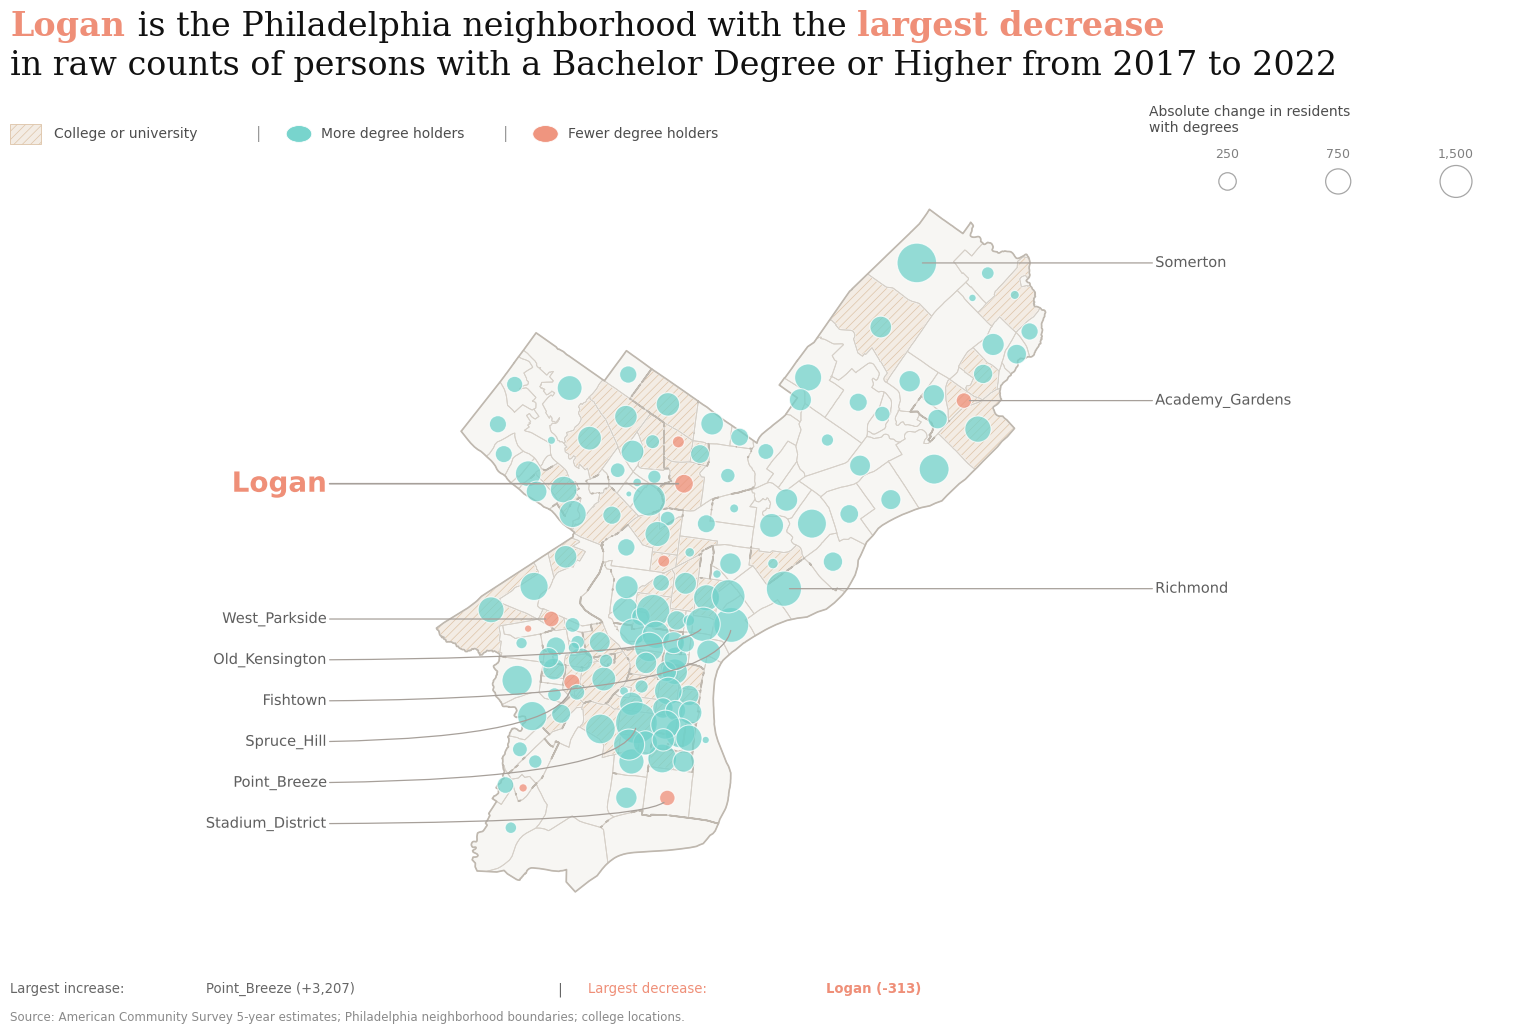

In [149]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

# ============================================================
# NYT-style Philadelphia neighborhood bubble map
# labels moved outside map with connector lines
# ============================================================

mpl.rcParams["hatch.linewidth"] = 0.5
mpl.rcParams["font.family"] = "DejaVu Sans"

# ----------------------------
# colors / styling
# ----------------------------
base_fill     = "#f7f6f3"
base_edge     = "#d6d0c8"
outer_edge    = "#bfb8af"

college_fill  = "#f3ece4"
college_hatch = "#ddc3a7"

inc_color     = "#71d2cb"
dec_color     = "#ef8f78"

title_color   = "#111111"
text_color    = "#4d4d4d"
subtle_text   = "#7f7f7f"
label_color   = "#5f5f5f"
leader_color  = "#a7a09a"

# ----------------------------
# prepare plotting data
# ----------------------------
plot_points = centroids[centroids["direction"] != "no change"].copy()

name_candidates = ["neighborhood", "NAME", "name", "LISTNAME", "MAPNAME"]
name_col = next((c for c in name_candidates if c in plot_points.columns), None)

if name_col is None:
    raise ValueError("Could not find a neighborhood name column in centroids.")

if neighborhoods.crs != plot_points.crs:
    plot_points = plot_points.to_crs(neighborhoods.crs)

# ----------------------------
# bubble scaling
# ----------------------------
abs_change = plot_points["college_change"].abs()

vmin = abs_change.min()
vmax = abs_change.max()

min_size = 18
max_size = 900
size_exp = 0.72

if vmax == vmin:
    plot_points["plot_size"] = (min_size + max_size) / 2
else:
    scaled = ((abs_change - vmin) / (vmax - vmin)) ** size_exp
    plot_points["plot_size"] = min_size + scaled * (max_size - min_size)

inc = plot_points[plot_points["direction"] == "increase"].copy()
dec = plot_points[plot_points["direction"] == "decrease"].copy()

# ----------------------------
# biggest increase / decrease
# ----------------------------
max_row = plot_points.loc[plot_points["college_change"].idxmax()]
min_row = plot_points.loc[plot_points["college_change"].idxmin()]

max_name = str(max_row[name_col]).title()
min_name = str(min_row[name_col]).title()
max_val = int(round(max_row["college_change"]))
min_val = int(round(min_row["college_change"]))

# ----------------------------
# choose labels
# ----------------------------
top_inc_labels = plot_points.nlargest(5, "college_change").copy()
top_dec_labels = plot_points.nsmallest(5, "college_change").copy()
label_df = pd.concat([top_inc_labels, top_dec_labels], axis=0).drop_duplicates(subset=[name_col]).copy()

anchor_names = [
    "Center City", "University City", "West Philadelphia", "North Philadelphia",
    "South Philadelphia", "Kensington", "Roxborough", "Chestnut Hill",
    "Fishtown", "Germantown"
]

if name_col in neighborhoods.columns:
    anchor_rows = neighborhoods[neighborhoods[name_col].isin(anchor_names)].copy()
else:
    anchor_rows = pd.DataFrame()

if len(anchor_rows) > 0:
    anchor_centroids = anchor_rows.copy()
    anchor_centroids["geometry"] = anchor_centroids.geometry.representative_point()
    for col in plot_points.columns:
        if col not in anchor_centroids.columns:
            anchor_centroids[col] = np.nan
    label_df = pd.concat(
        [label_df, anchor_centroids[label_df.columns]],
        axis=0
    ).drop_duplicates(subset=[name_col])

label_df = label_df.copy()
label_df["label_geom"] = label_df.geometry.representative_point()

# ----------------------------
# figure
# ----------------------------
fig, ax = plt.subplots(figsize=(17, 11.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ----------------------------
# base geography
# ----------------------------
neighborhoods.plot(
    ax=ax,
    color=base_fill,
    edgecolor="none",
    linewidth=0,
    zorder=1
)

neighborhoods[neighborhoods["has_college"]].plot(
    ax=ax,
    color=college_fill,
    edgecolor="none",
    linewidth=0,
    zorder=2
)

neighborhoods[neighborhoods["has_college"]].plot(
    ax=ax,
    facecolor="none",
    edgecolor=college_hatch,
    hatch="////",
    linewidth=0,
    zorder=2.4
)

neighborhoods.boundary.plot(
    ax=ax,
    color="#fbfaf8",
    linewidth=1.3,
    zorder=2.8
)

neighborhoods.boundary.plot(
    ax=ax,
    color=base_edge,
    linewidth=0.72,
    zorder=3
)

city_outline = neighborhoods.unary_union.boundary
try:
    import geopandas as gpd
    gpd.GeoSeries([city_outline], crs=neighborhoods.crs).plot(
        ax=ax,
        color=outer_edge,
        linewidth=1.2,
        zorder=3.2
    )
except Exception:
    neighborhoods.boundary.plot(
        ax=ax,
        color=outer_edge,
        linewidth=1.0,
        zorder=3.2
    )

# ----------------------------
# bubbles
# ----------------------------
dec.plot(
    ax=ax,
    markersize=dec["plot_size"],
    color=dec_color,
    alpha=0.74,
    edgecolor="white",
    linewidth=0.8,
    zorder=4
)

inc.plot(
    ax=ax,
    markersize=inc["plot_size"],
    color=inc_color,
    alpha=0.74,
    edgecolor="white",
    linewidth=0.8,
    zorder=5
)

# ----------------------------
# extent with extra room for outside labels
# ----------------------------
xmin, ymin, xmax, ymax = neighborhoods.total_bounds
xrange_ = xmax - xmin
yrange_ = ymax - ymin

left_label_x  = xmin - 0.18 * xrange_
right_label_x = xmax + 0.18 * xrange_

ax.set_xlim(xmin - 0.24 * xrange_, xmax + 0.24 * xrange_)
ax.set_ylim(ymin - 0.14 * yrange_, ymax + 0.14 * yrange_)

# ----------------------------
# external label placement
# split labels into left/right columns
# ----------------------------
label_df["x"] = label_df["label_geom"].x
label_df["y"] = label_df["label_geom"].y

mid_x = (xmin + xmax) / 2
left_df = label_df[label_df["x"] < mid_x].sort_values("y", ascending=False).copy()
right_df = label_df[label_df["x"] >= mid_x].sort_values("y", ascending=False).copy()

def spaced_positions(y_values, top, bottom, min_gap):
    y_sorted = list(y_values)
    adjusted = []
    prev = None

    for y in y_sorted:
        yy = min(y, top)
        if prev is not None and yy > prev - min_gap:
            yy = prev - min_gap
        adjusted.append(yy)
        prev = yy

    if len(adjusted) > 0 and adjusted[-1] < bottom:
        shift = bottom - adjusted[-1]
        adjusted = [y + shift for y in adjusted]

        for i in range(1, len(adjusted)):
            if adjusted[i] > adjusted[i - 1] - min_gap:
                adjusted[i] = adjusted[i - 1] - min_gap

    return adjusted

top_y = ymax + 0.05 * yrange_
bottom_y = ymin - 0.05 * yrange_
min_gap = 0.06 * yrange_

left_targets = spaced_positions(left_df["y"].tolist(), top_y, bottom_y, min_gap)
right_targets = spaced_positions(right_df["y"].tolist(), top_y, bottom_y, min_gap)

left_df["y_target"] = left_targets
right_df["y_target"] = right_targets

# ----------------------------
# draw connector labels
# ----------------------------
def draw_side_labels(df_side, x_text, ha):
    for _, row in df_side.iterrows():
        x0 = row["x"]
        y0 = row["y"]
        y1 = row["y_target"]

        label_text = str(row[name_col]).title()
        is_logan = label_text.lower() == "logan"

        ax.annotate(
            label_text,
            xy=(x0, y0),
            xytext=(x_text, y1),
            textcoords="data",
            ha=ha,
            va="center",
            fontsize=20 if is_logan else 10.5,
            color=dec_color if is_logan else label_color,
            fontweight="bold" if is_logan else "normal",
            zorder=6,
            path_effects=[
                pe.Stroke(linewidth=3.2 if is_logan else 3.0, foreground="white", alpha=0.96),
                pe.Normal()
            ],
            arrowprops=dict(
                arrowstyle="-",
                color=leader_color,
                lw=1.2 if is_logan else 0.9,
                shrinkA=0,
                shrinkB=4,
                connectionstyle="angle3,angleA=0,angleB=90"
            )
        )

draw_side_labels(left_df, left_label_x, "right")
draw_side_labels(right_df, right_label_x, "left")

# ----------------------------
# title + subtitle
# ----------------------------
title_y = 0.952
line_gap = 0.035
x0 = 0.07

# ---- LINE 1 ----
fig.text(
    x0, title_y + .0008,
    "Logan",
    fontsize=24,
    family="serif",
    color=dec_color,  # orange
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    x0 + 0.069, title_y,
    " is the Philadelphia neighborhood with the ",
    fontsize=24,
    family="serif",
    color=title_color,
    ha="left",
    va="top"
)

fig.text(
    .069 + 0.499, title_y + .0008,
    "largest decrease",
    fontsize=24,
    family="serif",
    color=dec_color,  # orange
    fontweight="bold",
    ha="left",
    va="top"
)

# ---- LINE 2 ----
fig.text(
    x0, title_y - line_gap,
    "in raw counts of persons with a Bachelor Degree or Higher from 2017 to 2022",
    fontsize=24,
    family="serif",
    color=title_color,
    ha="left",
    va="top"
)

fig.text(
    0.07, 0.908,
    "",
    fontsize=10.5,
    color="#666666",
    ha="left",
    va="top"
)

# ----------------------------
# inline legend
# ----------------------------
legend_y = 0.842
swatch_x = 0.07
swatch_w = 0.018
swatch_h = 0.018

fig.patches.append(
    plt.Rectangle(
        (swatch_x, legend_y - swatch_h / 2),
        swatch_w,
        swatch_h,
        transform=fig.transFigure,
        facecolor=college_fill,
        edgecolor=college_hatch,
        linewidth=0.6,
        hatch="////",
        zorder=20
    )
)

fig.text(
    swatch_x + swatch_w + 0.008, legend_y,
    "College or university",
    fontsize=10,
    color=text_color,
    va="center",
    ha="left"
)

fig.text(0.215, legend_y, "|", fontsize=11, color="#9a9a9a", va="center")

fig.patches.append(
    plt.Circle(
        (0.24, legend_y), 0.0075,
        transform=fig.transFigure,
        facecolor=inc_color,
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95
    )
)
fig.text(0.253, legend_y, "More degree holders", fontsize=10, color=text_color, va="center", ha="left")

fig.text(0.36, legend_y, "|", fontsize=11, color="#9a9a9a", va="center")

fig.patches.append(
    plt.Circle(
        (0.385, legend_y), 0.0075,
        transform=fig.transFigure,
        facecolor=dec_color,
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95
    )
)
fig.text(0.398, legend_y, "Fewer degree holders", fontsize=10, color=text_color, va="center", ha="left")

# ----------------------------
# size legend
# ----------------------------
size_vals = [250, 750, 1500]

if vmax == vmin:
    size_markers = [500, 500, 500]
else:
    size_markers = []
    for v in size_vals:
        sv = ((v - vmin) / (vmax - vmin))
        sv = max(0, min(1, sv))
        sv = sv ** size_exp
        size_markers.append(min_size + sv * (max_size - min_size))

ax_leg = fig.add_axes([0.74, 0.76, 0.21, 0.11])
ax_leg.axis("off")
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)

ax_leg.text(
    0.0, 0.98,
    "Absolute change in residents\nwith degrees",
    fontsize=10,
    color=text_color,
    va="top"
)

x_positions = [0.22, 0.53, 0.86]
y_circle = 0.36
y_label = 0.53

for x, s, label in zip(x_positions, size_markers, size_vals):
    ax_leg.scatter(
        x, y_circle,
        s=s,
        facecolor="none",
        edgecolor="#a6a6a6",
        linewidth=0.9
    )
    ax_leg.text(
        x, y_label,
        f"{label:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=subtle_text
    )

# ----------------------------
# top movers note
# ----------------------------
base_x = 0.07
y_pos = 0.075

fig.text(
    base_x, y_pos,
    "Largest increase: ",
    fontsize=9.5,
    color="#666666",
    ha="left"
)

fig.text(
    base_x + 0.115, y_pos,
    f"{max_name} ({max_val:+,})",
    fontsize=9.5,
    color="#666666",
    ha="left"
)

fig.text(
    base_x + 0.32, y_pos,
    " | ",
    fontsize=9.5,
    color="#666666",
    ha="left"
)

fig.text(
    base_x + 0.34, y_pos,
    "Largest decrease: ",
    fontsize=9.5,
    color=dec_color,
    ha="left"
)

fig.text(
    base_x + 0.48, y_pos,
    f"{min_name} ({min_val:+,})",
    fontsize=9.5,
    color=dec_color,
    ha="left",
    fontweight="bold"
)

# ----------------------------
# source
# ----------------------------
fig.text(
    0.07, 0.05,
    "Source: American Community Survey 5-year estimates; Philadelphia neighborhood boundaries; college locations.",
    fontsize=8.5,
    color="#8a8a8a",
    ha="left"
)

ax.set_axis_off()
plt.subplots_adjust(left=0.02, right=0.98, top=0.86, bottom=0.08)
plt.show()